# 01 · Corpus, cleaning and theme discovery

**Stakeholder:** a product / category manager who cannot read thousands of reviews.
**Question:** *What do customers love and hate about our products, how has it changed, and what should we fix first?*
**Data:** McAuley-Lab **Amazon Reviews 2023** (Hugging Face; categories *Appliances* and *All_Beauty*), real, messy text.

In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import pandas as pd, numpy as np
from IPython.display import Image
from reviewintel import config as C
rep = json.loads((C.ARTIFACTS_DIR / "cleaning_report.json").read_text())
pd.DataFrame(rep["steps"])

,step,removed,left
0,rating missing / outside 1-5,0,1412437
1,review text shorter than 30 characters after c...,248991,1163446
2,exact duplicate review text on the same product,8736,1154710
3,mostly non-Latin text (not English),1372,1153338
4,per-product cap (40 reviews),374300,779038
5,"sample to 60,000 reviews per category (whole r...",659071,119967


Cleaning decisions (all counted): HTML tags, URLs and **encoding damage** (`it\ufffds` in the source → `it's`) are repaired; reviews under 30 characters after cleaning are dropped (17.6% of the raw data - mostly "Good", "Love it"); exact duplicates on a product and mostly non-Latin text are removed.
**Sampling:** at most 40 reviews per product so blockbusters cannot dominate, and *whole review sets of products with ≥ 25 reviews are kept* so product-level analysis is possible (3,318 products, ~36 reviews each).

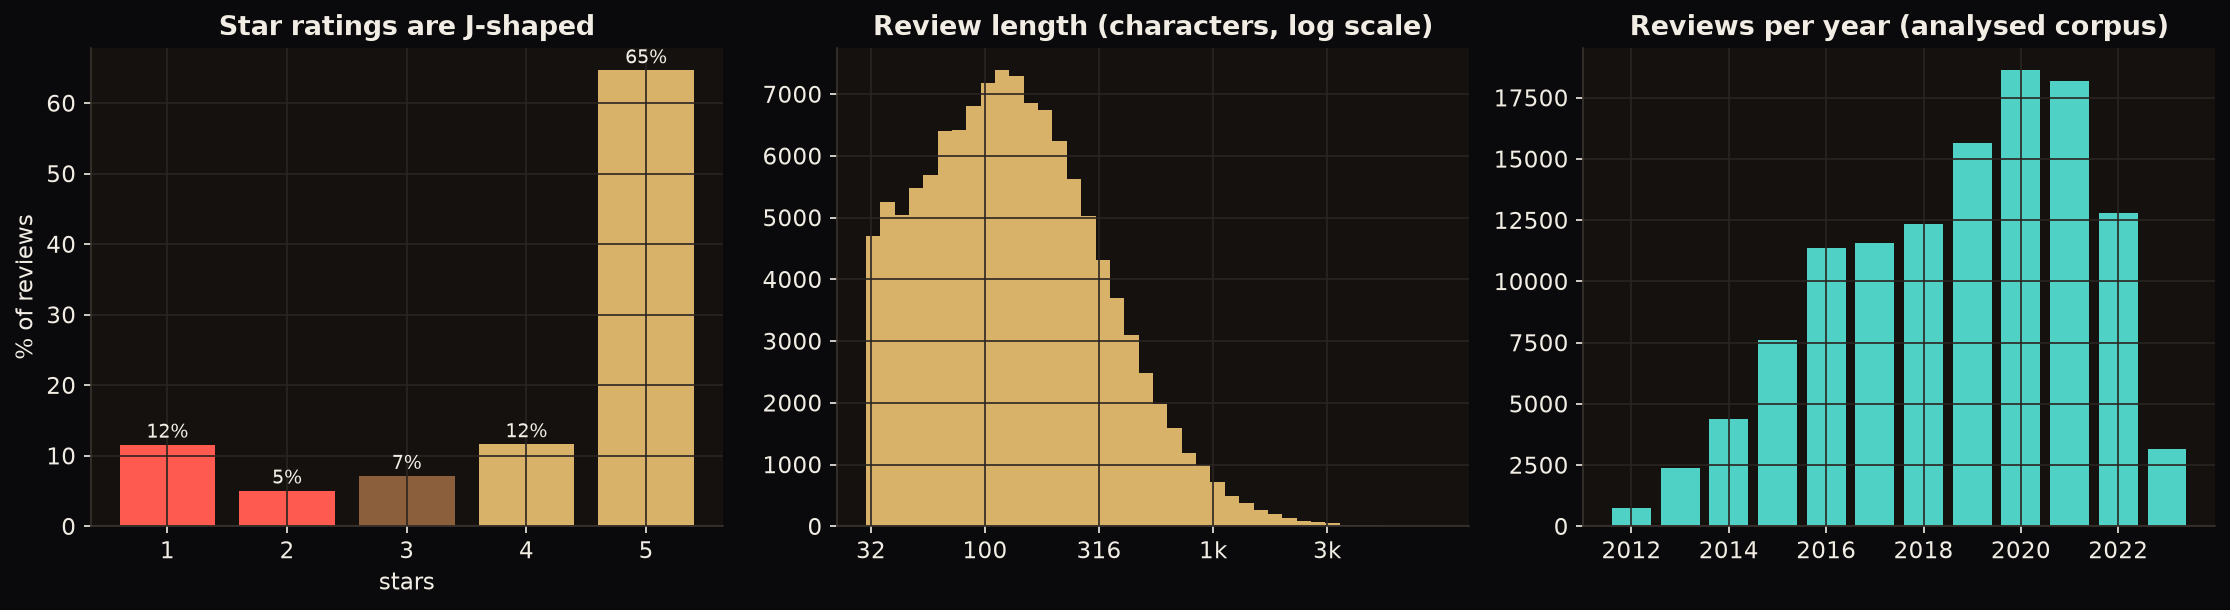

In [2]:
Image(str(C.FIGURES_DIR / "02_eda.png"))

In [3]:
r = pd.read_parquet(C.PROCESSED_DIR / "reviews.parquet")
print(r.groupby("category").rating.apply(lambda s: pd.Series({"neg_1_2": (s <= 2).mean(), "pos_4_5": (s >= 4).mean()})).unstack().round(3))
print("median length:", int(r.n_chars.median()), "chars; verified purchase:", round(r.verified_purchase.mean() * 100), "%")
r.groupby("category").product_title.apply(lambda s: s.dropna().sample(3, random_state=1).str.slice(0, 70).tolist())

            neg_1_2  pos_4_5
category                    
All_Beauty    0.207    0.708
Appliances    0.125    0.818
median length: 126 chars; verified purchase: 93 %


category
All_Beauty    [Roux Rejuvenating Keratin 233 Repair and Shin...
Appliances    [DishTrick DISHEXTEND Dishwasher Extension Bun...
Name: product_title, dtype: object

**Findings**
* Ratings are J-shaped (65% 5★, 17% 1-2★, 7% 3★): accuracy alone is meaningless for sentiment, so macro-F1 and negative-class F1 are reported.
* Beauty has almost twice the negative share (20.7% vs 12.5%).
* The "All_Beauty" category also contains items that are not beauty products at all (e.g. printer ink), a real labelling problem of the source; themes are discovered from the text, not from the category label.

### Theme discovery (BERTopic on sentence embeddings)

In [4]:
meta = json.loads((C.ARTIFACTS_DIR / "theme_meta.json").read_text()); print(meta)
th = pd.read_parquet(C.ARTIFACTS_DIR / "themes.parquet")
names = {k: v["name"] for k, v in json.loads((C.ARTIFACTS_DIR / "theme_names.json").read_text()).items()}
th["name"] = [names[f"{r.category}|{r.topic}"] for r in th.itertuples()]
th[["category", "name", "label", "review_share_pct", "avg_rating", "neg_lift"]].round(2).head(12)

{'n_sentences': 320670, 'n_reviews': 119967, 'classifier': {'Appliances': {'held_out_accuracy_vs_embedding_assignment': 0.7664633127193715, 'n_themes': 29}, 'All_Beauty': {'held_out_accuracy_vs_embedding_assignment': 0.7593297476210178, 'n_themes': 29}}, 'runtime_min': 37.47802043755849, 'n_topics_requested': 30}


,category,name,label,review_share_pct,avg_rating,neg_lift
0,Appliances,"Price, brand & quality (generic)","return, price, brand, quality",22.05,4.24,1.19
1,Appliances,Easy installation,"install, easy, easy install, works",17.24,4.51,0.57
2,Appliances,"Washers, dryers & dishwashers","dryer, washer, dishwasher, machine",16.16,4.41,0.83
3,Appliances,Water filters & taste,"filter, filters, water, taste",14.75,4.26,1.10
4,Appliances,Repairs & replacement parts,"replacement, repair, broke, problem",12.82,4.03,1.54
5,Appliances,Ice makers & fridges,"ice, fridge, refrigerator, maker",11.75,4.25,1.11
6,Appliances,Coffee makers & pods,"coffee, cup, grounds, pod",11.25,4.32,1.00
7,Appliances,Fit & compatibility,"fit, size, perfect, fits",10.79,4.32,0.92
8,Appliances,Build quality (flimsy plastic),"plastic, sturdy, metal, flimsy",9.74,4.03,1.32
9,Appliances,Stopped working after months,"months, working, lasted, stopped working",8.92,3.79,1.97


**Method.** Reviews → 320,670 sentences (4-60 words) → MiniLM embeddings → per category BERTopic (UMAP → HDBSCAN → c-TF-IDF) on a 30k-sentence sample that deliberately over-samples sentences from ≤3★ reviews, merged to ~30 themes → every sentence assigned to the nearest theme centroid.
*Theme names* are written by me from the top words and example sentences (`artifacts/theme_names.json`); the raw top-words label is kept next to it. Themes that are generic ("Price, brand & quality", star-rating chatter) are flagged and excluded from product complaint/strength lists.

**Complaint lift** = P(1-2★ | theme mentioned) ÷ P(1-2★). It is a *correlation* with unhappy reviews, not proof that the theme caused the rating.

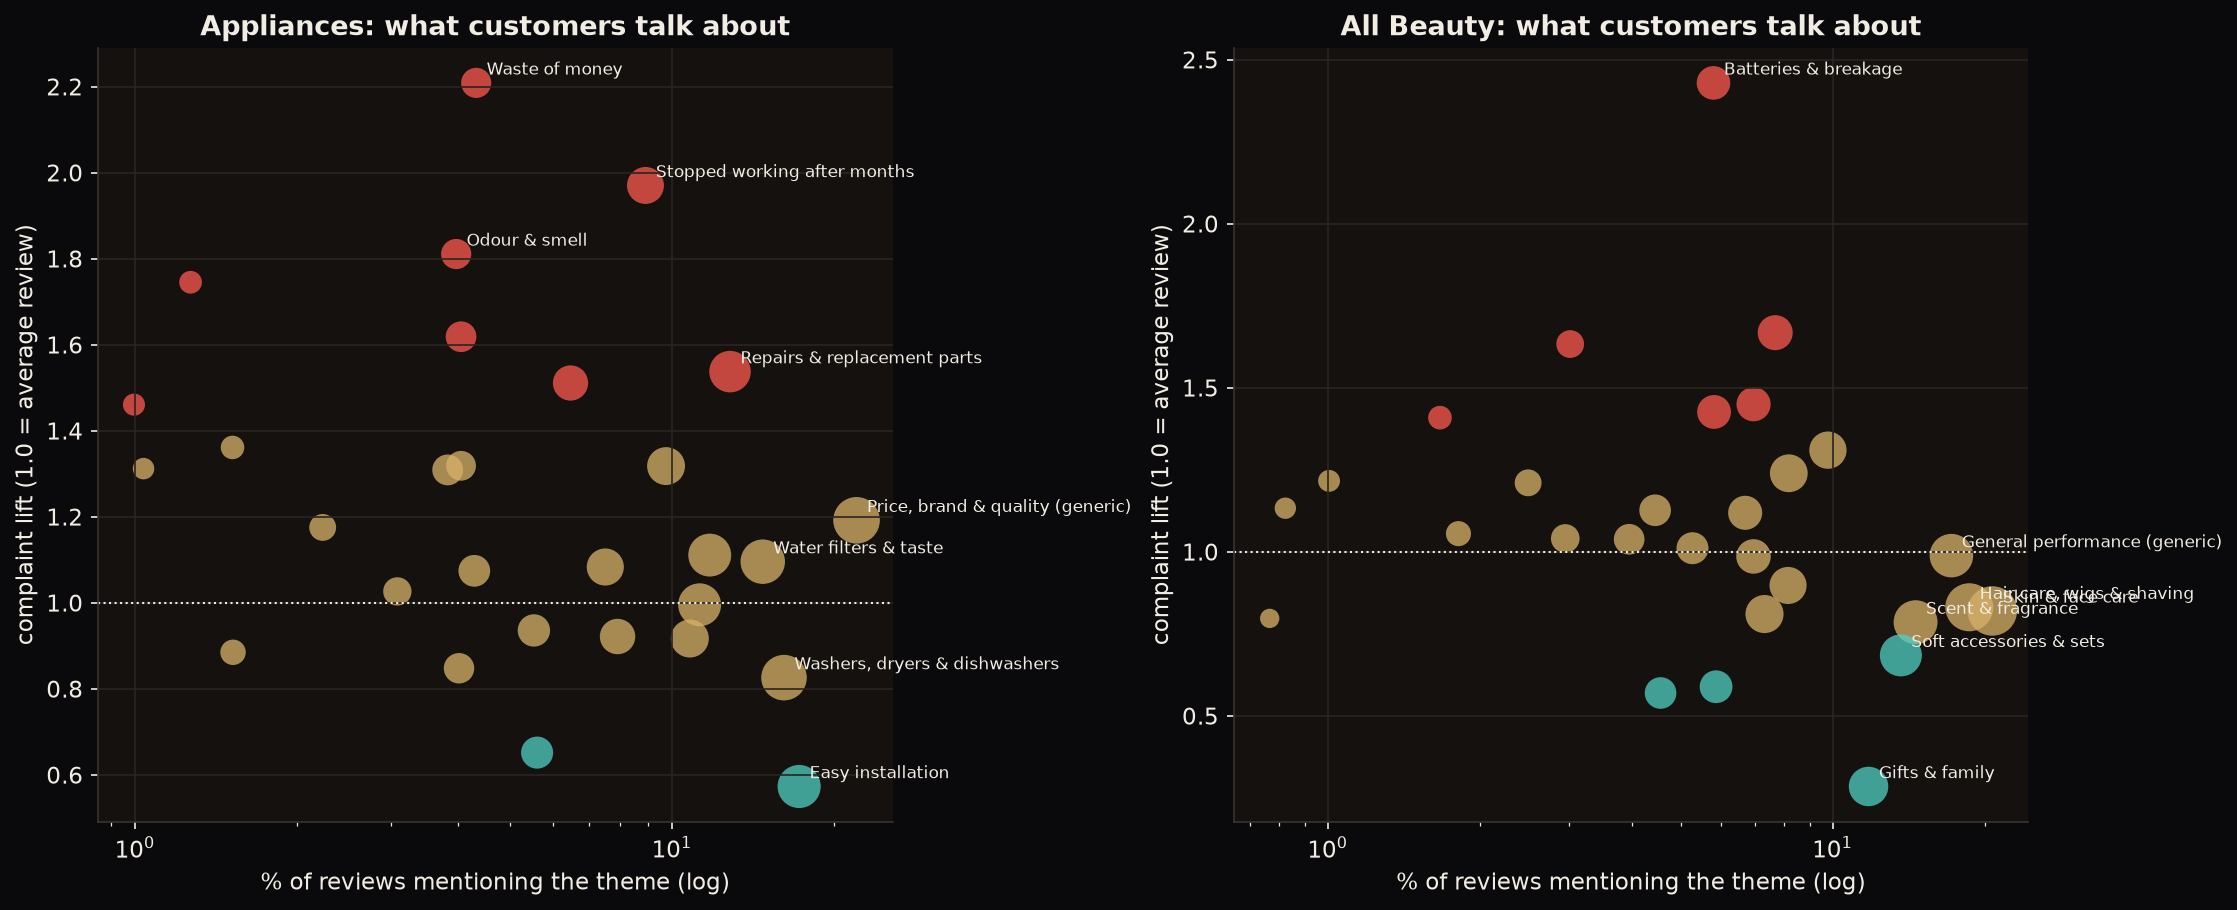

In [5]:
Image(str(C.FIGURES_DIR / "05_theme_map.png"))

In [6]:
big = th[(th.review_share_pct > 1.5) & ~th.name.str.contains("generic")]
for cat, g in big.groupby("category"):
    print(cat); print(g.nlargest(5, "neg_lift")[["name", "review_share_pct", "avg_rating", "neg_lift"]].round(2).to_string(index=False), "\n")

All_Beauty
                       name  review_share_pct  avg_rating  neg_lift
       Batteries & breakage              5.81        2.75      2.43
          Returns & refunds              7.69        3.49      1.67
Not as pictured / described              3.02        3.35      1.63
         Unmet expectations              6.97        3.54      1.45
     Bottles, pumps & leaks              5.82        3.56      1.43 

Appliances
                        name  review_share_pct  avg_rating  neg_lift
              Waste of money              4.32        3.73      2.21
Stopped working after months              8.92        3.79      1.97
               Odour & smell              3.96        3.84      1.81
      Doors, handles & locks              4.05        3.87      1.62
 Repairs & replacement parts             12.82        4.03      1.54 



**Insights**
* **Appliances:** the worst themes are *waste of money* (2.2×), *stopped working after months* (2.0×, mentioned by 9% of reviews), *odour & smell* (1.8×) and *doors/handles/locks* (1.6×); *easy installation* is the strongest praise (0.57×).
* **Beauty:** *batteries & breakage* (2.4×, avg 2.75★), *returns & refunds* (1.7×), *not as pictured* (1.6×), *unmet expectations* (1.5×); *gifts & family* is by far the happiest theme (0.28×, 4.61★).
* Durability and "not as described" are quality/listing problems; price/value complaints follow them.

### Theme assignment quality

In [7]:
print(meta["classifier"])
th_ex = pd.read_parquet(C.ARTIFACTS_DIR / "theme_examples.parquet")
th_ex.merge(th[["category", "topic", "name"]], on=["category", "topic"]).query("kind == 'complaint' and name in ['Stopped working after months', 'Odour & smell']").groupby("name").sentence.apply(lambda s: s.head(3).tolist())

{'Appliances': {'held_out_accuracy_vs_embedding_assignment': 0.7664633127193715, 'n_themes': 29}, 'All_Beauty': {'held_out_accuracy_vs_embedding_assignment': 0.7593297476210178, 'n_themes': 29}}


name
Odour & smell                   [We noticed a really odd smell after using it ...
Stopped working after months    [Lasted just two months., Only lasted 1 month....
Name: sentence, dtype: object

The light TF-IDF theme classifier used in the deployed app agrees with the embedding-based assignment on ~76% of held-out sentences (29 classes). It is good enough for showing aspects of a pasted review, but sentence-level themes are approximate: a sentence can belong to two themes, and short sentences are ambiguous.

### Complaint trends over time

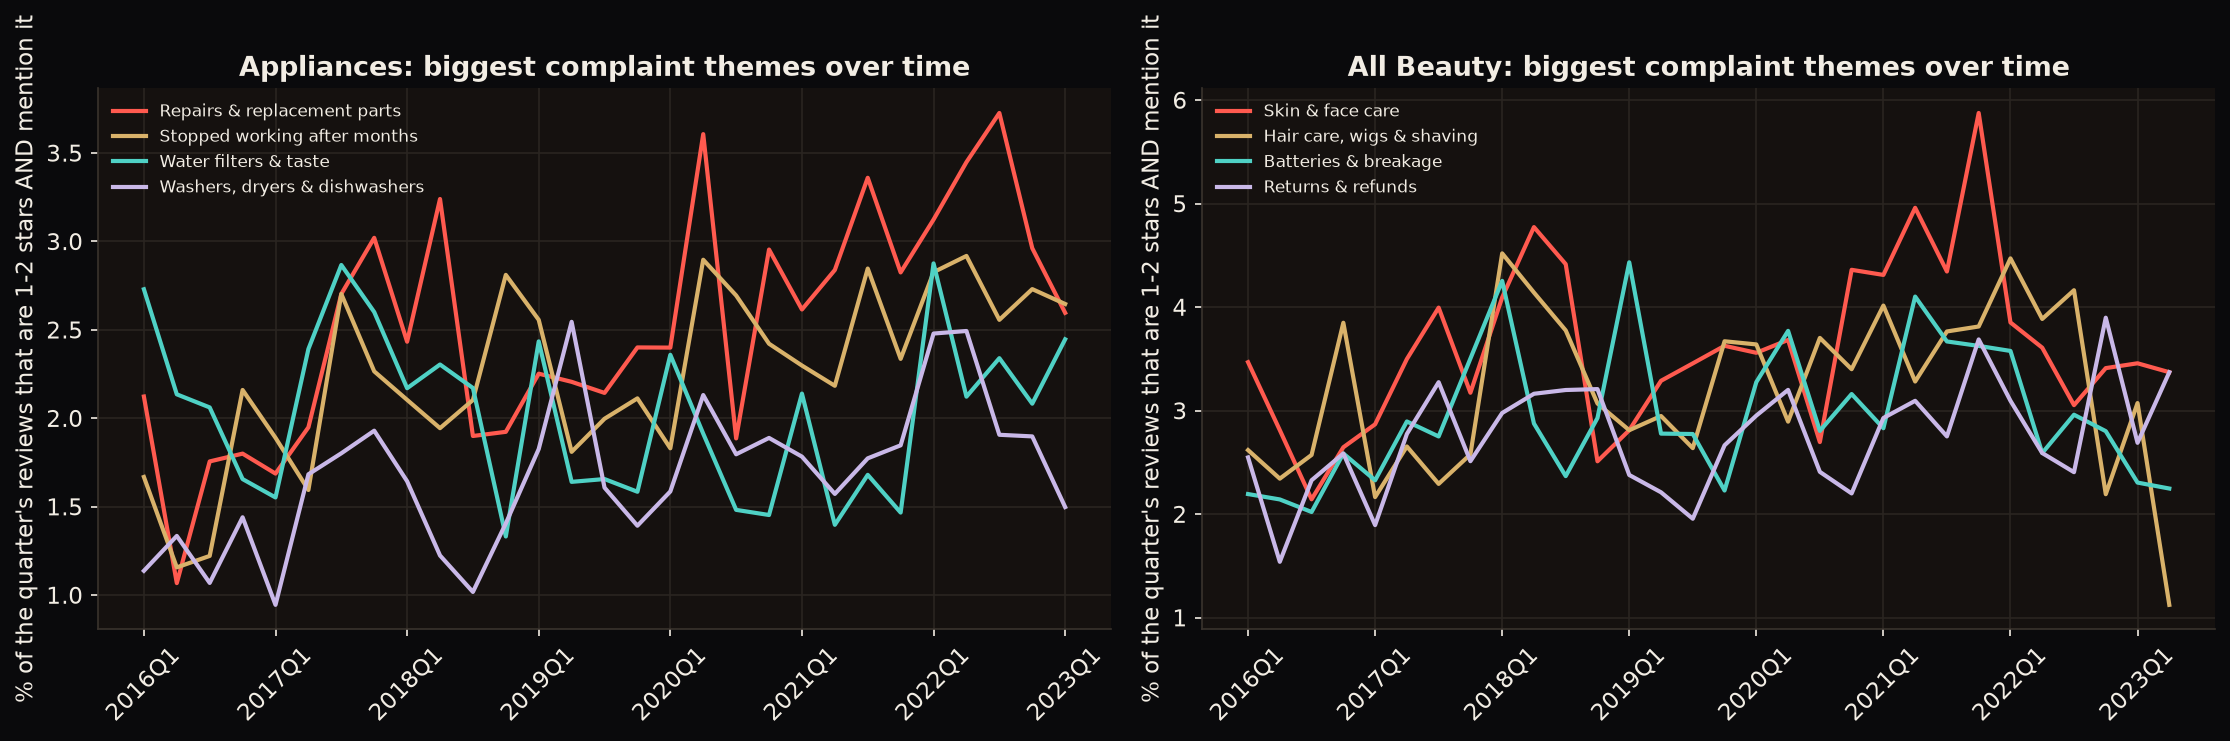

In [8]:
Image(str(C.FIGURES_DIR / "06_complaint_trends.png"))

Quarterly complaint shares are noisy (a few hundred to a few thousand reviews per quarter in this sampled corpus). In Appliances, *repairs & replacement parts* and *stopped working* complaints creep up after 2020, but the trends are shown for direction only; no statistical test is claimed.